In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv
import numpy as np
import ast
import seaborn as sns
import ast
import os

from sklearn.metrics import mean_squared_error


TASC_VColor         = "#57B8FF"  # keep
TASC_permute_VColor = "#2176AE"  # keep
SC_VColor           = "#7ED957"  # fresher green, balanced against blue tones
RSC_VColor          = "#FF9F40"  # brighter orange, closer in vibrancy
CIM_VColor          = "#E255A1"  # vivid magenta, still distinct but harmonized


In [2]:
df = pd.read_csv("../../aistats_exp1/logs/exp1_try7.csv")
header = ["seed_datagen", "seed_learning", "d_true", "N", "T", "T0", "N1", "d",
        "high_covariance", "loglikelihood", "loglikelihood_permute",
        "pred_tasc", "pred_tasc_permute", "pred_rsc", "pred_sc", "pred_cim", "cim_posterior_lower", "cim_posterior_upper",
        "tasc_target_var_estimates", "tasc_permute_target_var_estimates",
        "R_tasc", "R_tasc_permute",
        "ys", "ys_signal",
        ]

df = df.fillna("all small")

# Convert string representation of lists back to lists
list_cols = ['pred_tasc', 'pred_tasc_permute',
       'pred_rsc', 'pred_sc', 'pred_cim', 'cim_posterior_lower',
       'cim_posterior_upper', 'tasc_target_var_estimates','tasc_permute_target_var_estimates', 'ys', 'ys_signal']

for col in list_cols:
    df[col] = df[col].apply(ast.literal_eval)

# tasc lower/upper bound
df["tasc_upper"] = df.apply(lambda row: row["pred_tasc"] + 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)
df["tasc_lower"] = df.apply(lambda row: row["pred_tasc"] - 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)

# Compute RMSE for each method
pred_cols = ['pred_tasc', 'pred_tasc_permute', 'pred_rsc', 'pred_sc', 'pred_cim']

for col in pred_cols:
    df["rmse_"+col] = df.apply(
        lambda row: mean_squared_error(
            row["ys_signal"][row["T0"]:], row[col][row["T0"]:]
            # row["ys"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )


df_additional = df[df["high_covariance"]=="both"]
print(df_additional.shape)
df_additional.head()

(100, 31)


,seed_datagen,seed_learning,d_true,N,T,T0,N1,d,high_covariance,loglikelihood,...,R_tasc_permute,ys,ys_signal,tasc_upper,tasc_lower,rmse_pred_tasc,rmse_pred_tasc_permute,rmse_pred_rsc,rmse_pred_sc,rmse_pred_cim
3,0,1000,5,50,100,50,1000,5,both,-4451.335449,...,"[2.267975330352783, 1.4768390655517578, 1.5716...","[-0.4697660121287641, 0.06287620943578863, -2....","[0.008355080273952037, 0.16403879729729112, -1...","[0.40696167485228946, 0.819463468790167, -1.04...","[-0.22311853901854922, 0.02612587094295682, -1...",0.378236,0.854513,0.535726,0.625289,0.946605
7,1,1000,5,50,100,50,1000,5,both,-4467.011230,...,"[1.7645338773727417, 1.9899626970291138, 1.704...","[0.1559362711476038, 1.1706624415233933, 0.446...","[-0.0034424701199184996, 0.9434378078403388, -...","[0.2525559815215329, 1.0038266617250042, 0.038...","[-0.20478262031547825, 0.5109943908262652, -0....",1.856691,1.719744,1.267251,0.955167,1.314218
11,2,1000,5,50,100,50,1000,5,both,-4432.165039,...,"[1.5713002681732178, 1.7649421691894531, 1.678...","[2.316163351120677, -2.0590179932789363, 0.760...","[0.3600507583251301, -0.2865903845459174, -0.8...","[0.34415532811882743, 0.1540403574251471, -0.3...","[-0.1896703259587551, -0.41553928549521546, -0...",2.231916,2.268197,2.034073,1.495704,3.132221
15,3,1000,5,50,100,50,1000,5,both,-4296.524902,...,"[1.792628526687622, 1.684256911277771, 1.62987...","[-4.199272315585142, 3.0222044269669635, 2.953...","[-2.438346390619544, 3.3297478358455335, 0.181...","[-2.167010977304643, 3.423649621342958, 1.3498...","[-3.2497494673364704, 2.33487193551129, 0.2547...",0.291607,0.267179,0.351898,0.265593,0.889895
19,4,1000,5,50,100,50,1000,5,both,-4313.375488,...,"[1.6254467964172363, 1.63362717628479, 1.69053...","[1.1607060536776177, 0.718358623969211, 1.3680...","[-0.23560539387898619, 0.34226158141815405, 1....","[0.33467886644829103, 1.229614267223806, 1.703...","[-0.602522112908252, 0.27592038167145777, 0.74...",0.195194,0.327964,0.310928,0.287795,0.418686


In [3]:
df = pd.read_csv("exp3_try2.csv")
header = ["seed_datagen", "seed_learning", "d_true", "N", "T", "T0", "N1", "d",
        "high_covariance", "loglikelihood", "loglikelihood_permute",
        "pred_tasc", "pred_tasc_permute", "pred_rsc", "pred_sc", "pred_cim", "cim_posterior_lower", "cim_posterior_upper",
        "tasc_target_var_estimates", "tasc_permute_target_var_estimates",
        "R_tasc", "R_tasc_permute",
        "ys", "ys_signal",
        ]



# Convert string representation of lists back to lists
list_cols = ['pred_tasc',
       'pred_rsc', 'pred_sc', 'pred_cim', 'cim_posterior_lower',
       'cim_posterior_upper', 'tasc_target_var_estimates', 'ys', 'ys_signal']

for col in list_cols:
    df[col] = df[col].apply(ast.literal_eval)

# tasc lower/upper bound
df["tasc_upper"] = df.apply(lambda row: row["pred_tasc"] + 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)
df["tasc_lower"] = df.apply(lambda row: row["pred_tasc"] - 1.96 * np.sqrt(row["tasc_target_var_estimates"]), axis=1)



# Compute RMSE for each method
pred_cols = ['pred_tasc','pred_rsc', 'pred_sc', 'pred_cim']

for col in pred_cols:
    print(col)
    df["rmse_"+col] = df.apply(
        lambda row: mean_squared_error(
            row["ys_signal"][row["T0"]:], row[col][row["T0"]:]
            # row["ys"][row["T0"]:], row[col][row["T0"]:]
        ),
        axis=1
    )

df = pd.concat([df, df_additional], ignore_index=True)
print(df.shape)
df.head()


pred_tasc
pred_rsc
pred_sc
pred_cim
(500, 31)


,seed_datagen,seed_learning,d_true,N,T,T0,N1,d,high_covariance,loglikelihood,...,R_tasc_permute,ys,ys_signal,tasc_upper,tasc_lower,rmse_pred_tasc,rmse_pred_rsc,rmse_pred_sc,rmse_pred_cim,rmse_pred_tasc_permute
0,0,1000,5,10,100,50,1000,5,both,-1433.916138,...,NaN,"[0.9902691608327719, -1.7430691706479364, 0.16...","[0.931630294585883, -1.0455882198859985, 0.985...","[1.3466993200046888, -0.674239390801473, 1.425...","[0.5914092434184679, -1.592864519644694, 0.404...",0.417432,0.446801,0.337282,0.594310,NaN
1,0,1000,5,20,100,50,1000,5,both,-2056.470703,...,NaN,"[2.3332918246716847, -0.4443942514061958, 0.92...","[1.462956680295064, -0.1690439969732479, -0.33...","[2.167533153948638, 0.5284574014827227, 0.6311...","[1.3660366588260204, -0.3291189653560137, -0.2...",0.984500,0.864218,1.467923,0.752279,NaN
2,0,1000,5,100,100,50,1000,5,both,-8474.672852,...,NaN,"[3.265506346769871, 2.404217878475679, 1.03978...","[1.696769363195478, 0.4698390268966437, 0.5701...","[2.336578357892937, 1.1380535556662597, 1.1214...","[1.3802104108753737, 0.20821676713342302, 0.19...",0.276484,0.399789,0.658871,0.929783,NaN
3,0,1000,5,200,100,50,1000,5,both,-17650.818359,...,NaN,"[0.4495367833275489, -0.11393313133408708, -1....","[-0.6694630074118154, -0.20451252064361566, 0....","[0.4881358074403416, 0.2979299233588444, 0.170...","[-0.6019949393726002, -0.7839849100741612, -0....",1.394097,0.994652,1.687496,1.091679,NaN
4,1,1000,5,10,100,50,1000,5,both,-1363.180908,...,NaN,"[-0.2450296202466523, 0.07202140120373313, 0.0...","[0.43800113673103436, 0.27792492572847377, -0....","[0.9398215415265442, 1.3203850993864605, 0.687...","[0.09863346793390504, 0.4447847595460345, -0.2...",0.964137,0.374190,0.298460,0.726663,NaN


In [4]:
# df = best_df.copy()
id_vars = ["N"]

# Map columns to method names
method_map = {
    "rmse_pred_tasc": "TASC",
    # "rmse_pred_tasc_permute": "TASC-permuted",
    "rmse_pred_rsc": "RSC",
    "rmse_pred_sc": "SC",
    "rmse_pred_cim": "CIM"
}

# Melt in one go
df_long = df.melt(
    id_vars=id_vars,
    value_vars=method_map.keys(),
    value_name="rmse",
    var_name="variable"
)

# Map variable names to methods
df_long["method"] = df_long["variable"].map(method_map)

# Drop the original column identifier if not needed
df_long = df_long.drop(columns="variable")

print(df_long.shape)
df_long.head()


(2000, 3)


,N,rmse,method
0,10,0.417432,TASC
1,20,0.984500,TASC
2,100,0.276484,TASC
3,200,1.394097,TASC
4,10,0.964137,TASC


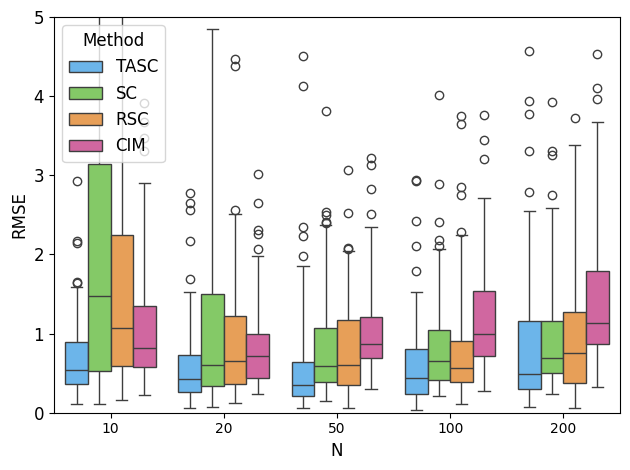

In [8]:
# small R first

df_plot = df_long
hue_order = ["TASC", "SC", "RSC", "CIM"]
# xticks = [0, 1]
# xtickers = ["R small, Q small", "R small, Q big"]
font = 12

# plt.figure(figsize=(9, 5))

# ax = sns.violinplot(
ax = sns.boxplot(
    data=df_plot,
    x="N", 
    y="rmse",
    hue="method",
    hue_order = hue_order,
    whis=[0, 95],
    palette={"TASC": TASC_VColor, "TASC-permuted":TASC_permute_VColor, "RSC": RSC_VColor, "SC": SC_VColor, "CIM": CIM_VColor},
    # linewidth=1.5,
    # inner="quartile",
    # cut=0
)

plt.xlabel("N", fontsize=font)
plt.ylabel("RMSE", fontsize=font)
# plt.xticks(xticks, xtickers, fontsize=font)
plt.yticks(fontsize=font)
plt.ylim(bottom=0, top=5)
plt.legend(title="Method", fontsize=font, title_fontsize=font)
plt.tight_layout()
plt.savefig('exp3_varying_N.png')
plt.show()
